# Basic CNN for Traffic Sign Classification using GTSRB

## Introduction

A Convolutional Neural Network (CNN) is a deep learning model commonly used for image classification.  
In this notebook, we build a **Basic CNN model** to classify German traffic signs using the **GTSRB dataset**.

This project follows the same teaching-friendly structure as a DNN notebook:

1. Library imports  
2. Dataset download  
3. Dataset loading  
4. Dataset understanding and sample visualization  
5. Preprocessing and normalization  
6. Train/validation/test preparation  
7. Basic CNN model building  
8. Training configuration  
9. Model saving  
10. Evaluation and prediction visualization


# Importing Required Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Download The GTSRB Dataset


In [2]:
# Download latest version of GTSRB from Kaggle
path = kagglehub.dataset_download(
    "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
)

print("Path to dataset files:", path)
print("Files/Folders inside dataset:")
print(os.listdir(path))

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign
Files/Folders inside dataset:
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


# Define Basic Settings

In [3]:
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
SEED = 42

train_dir = os.path.join(path, "Train")
test_csv_path = os.path.join(path, "Test.csv")

print("Train directory exists:", os.path.exists(train_dir))
print("Test CSV exists:", os.path.exists(test_csv_path))

Train directory exists: True
Test CSV exists: True


# Load Image Paths and Labels

The GTSRB training data is stored in class-wise folders:

```text
Train/
   0/
   1/
   2/
   ...
```

Each folder name is the class label.

In [4]:
image_paths = []
labels = []

for class_id in sorted(os.listdir(train_dir), key=lambda x: int(x)):
    class_folder = os.path.join(train_dir, class_id)

    if os.path.isdir(class_folder):
        for image_name in os.listdir(class_folder):
            image_path = os.path.join(class_folder, image_name)

            if image_path.lower().endswith((".png", ".jpg", ".jpeg", ".ppm")):
                image_paths.append(image_path)
                labels.append(int(class_id))

image_paths = np.array(image_paths)
labels = np.array(labels)

NUM_CLASSES = len(np.unique(labels))

print("Total training images found:", len(image_paths))
print("Total labels found:", len(labels))
print("Number of classes:", NUM_CLASSES)
print("Class IDs:", np.unique(labels))

Total training images found: 39209
Total labels found: 39209
Number of classes: 43
Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


## 5. Class Name Mapping

GTSRB contains **43 traffic sign classes**.  
The model predicts class numbers, but this dictionary helps convert class IDs into readable labels.


In [5]:
class_names = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

print("Example:")
print("Class 12 =", class_names[12])

Example:
Class 12 = Priority road


## 6. Show Sample Images from the Dataset

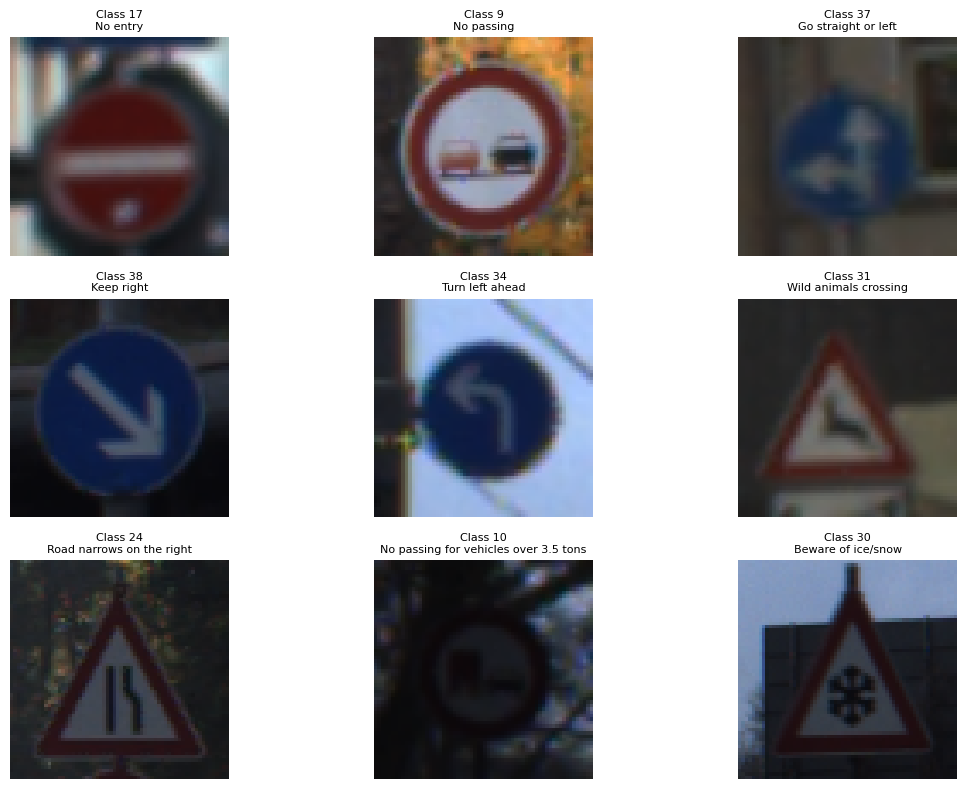

In [6]:
def show_sample_images(image_paths, labels, num_samples=9):
    plt.figure(figsize=(12, 8))
    sample_indices = random.sample(range(len(image_paths)), num_samples)

    for i, idx in enumerate(sample_indices):
        image = tf.io.read_file(image_paths[idx])
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

        label = int(labels[idx])

        plt.subplot(3, 3, i + 1)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(f"Class {label}\n{class_names[label]}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(image_paths, labels)

## 7. Train and Validation Split

The original training set is split into:

- Training set: 80%
- Validation set: 20%

The official test set is loaded separately from `Test.csv`.


In [7]:
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))

Training images: 31367
Validation images: 7842


## 8. Load Official Test Set

In [8]:
test_df = pd.read_csv(test_csv_path)

test_image_paths = []
test_labels = []

for _, row in test_df.iterrows():
    relative_path = row["Path"]
    image_path = os.path.join(path, relative_path)

    if os.path.exists(image_path):
        test_image_paths.append(image_path)
        test_labels.append(int(row["ClassId"]))

test_image_paths = np.array(test_image_paths)
test_labels = np.array(test_labels)

print("Test images:", len(test_image_paths))
print("Test labels:", len(test_labels))

Test images: 12630
Test labels: 12630


## 9. Preprocessing and Normalization

Each image is:

- Read from file
- Decoded as RGB
- Resized to 64 × 64
- Normalized to the range 0 to 1


In [9]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(label, tf.int32)

    return image, label


def create_dataset(images, labels, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_imgs, train_labels, shuffle=True)
val_ds = create_dataset(val_imgs, val_labels, shuffle=False)
test_ds = create_dataset(test_image_paths, test_labels, shuffle=False)

print("Datasets created successfully.")

Datasets created successfully.


## 10. Build Basic CNN Model

This is a simple CNN model suitable for teaching beginners.

Regularization used:

- L2 regularization
- Dropout
 New Section

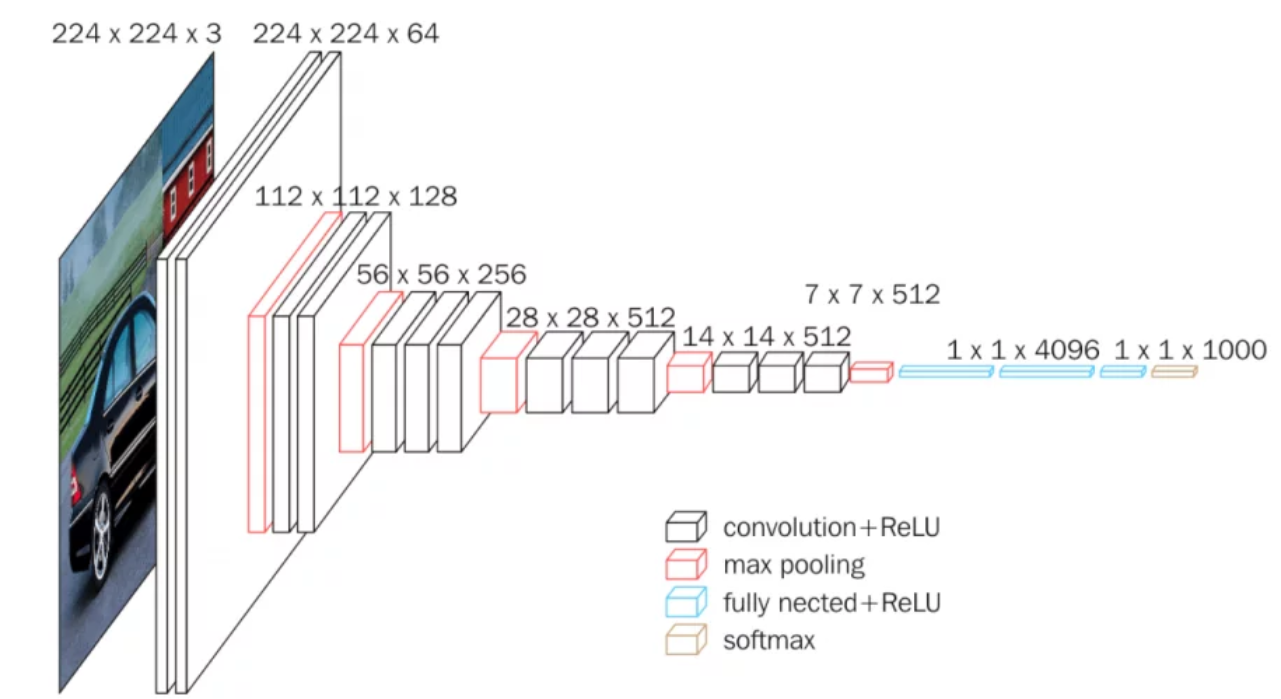

In [10]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,147,499 (4.38 MB)

 Trainable params: 1,147,499 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile and Train the Model

Training settings:

- Maximum epochs: 20
- Early stopping patience: 3
- Loss function: sparse categorical crossentropy
- Optimizer: Adam


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    min_delta=0.01,          # minimum improvement required
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_gtsrb_basic_cnn.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,     # saves only when validation accuracy improves
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.2725 - loss: 2.6690
Epoch 1: val_accuracy improved from None to 0.71576, saving model to best_gtsrb_basic_cnn.keras

Epoch 1: finished saving model to best_gtsrb_basic_cnn.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 181s 171ms/step - accuracy: 0.4025 - loss: 2.0528 - val_accuracy: 0.7158 - val_loss: 1.0377
Epoch 2/20
977/981 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6168 - loss: 1.2075
Epoch 2: val_accuracy improved from 0.71576 to 0.90232, saving model to best_gtsrb_basic_cnn.keras

Epoch 2: finished saving model to best_gtsrb_basic_cnn.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - accuracy: 0.6672 - loss: 1.0636 - val_accuracy: 0.9023 - val_loss: 0.4641
Epoch 3/20
978/981 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7885 - loss: 0.7507
Epoch 3: val_accuracy improved from 0.90232 to 0.96850, saving model to best_gtsrb_basic_cnn.keras

Epoch 3: finished saving model to best_gtsrb_basic_cnn.keras
981/981 ━━━━━━━━━━

## 12. Save the Final Model

The model is saved before final evaluation.


In [12]:
model.save("final_gtsrb_basic_cnn.keras")
print("Model saved successfully.")

Model saved successfully.


## 13. Evaluate the Model

In [13]:
# Make sure the model is compiled before evaluation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

395/395 ━━━━━━━━━━━━━━━━━━━━ 39s 95ms/step - accuracy: 0.9424 - loss: 0.3730
Test Loss: 0.3729648292064667
Test Accuracy: 0.942359447479248


## 14. Classification Report

In [14]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_labels)

target_names = [class_names[i] for i in range(NUM_CLASSES)]

print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    zero_division=0
))

                                             precision    recall  f1-score   support

                        Speed limit 20 km/h       1.00      0.43      0.60        60
                        Speed limit 30 km/h       0.94      0.96      0.95       720
                        Speed limit 50 km/h       0.97      0.99      0.98       750
                        Speed limit 60 km/h       0.99      0.73      0.84       450
                        Speed limit 70 km/h       0.88      0.97      0.93       660
                        Speed limit 80 km/h       0.78      0.98      0.87       630
                 End of speed limit 80 km/h       1.00      0.97      0.98       150
                       Speed limit 100 km/h       0.98      0.87      0.92       450
                       Speed limit 120 km/h       0.90      0.94      0.92       450
                                 No passing       0.97      1.00      0.98       480
      No passing for vehicles over 3.5 tons       1.00      0.99

## 15. Training Curves

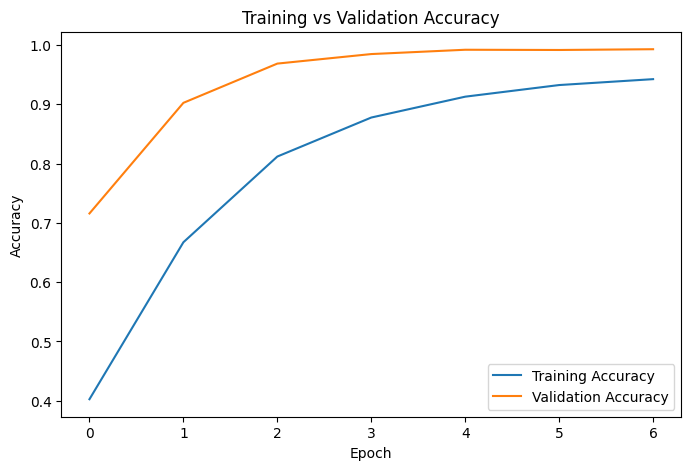

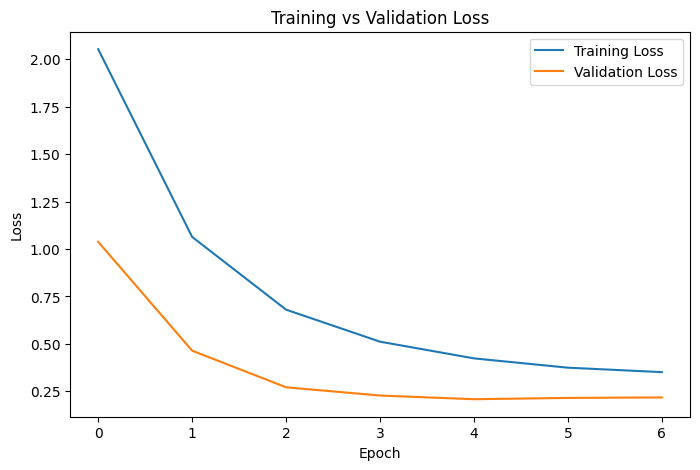

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## 16. Sample Predictions

`Pred` means the class predicted by the CNN.  
`True` means the actual correct class label.


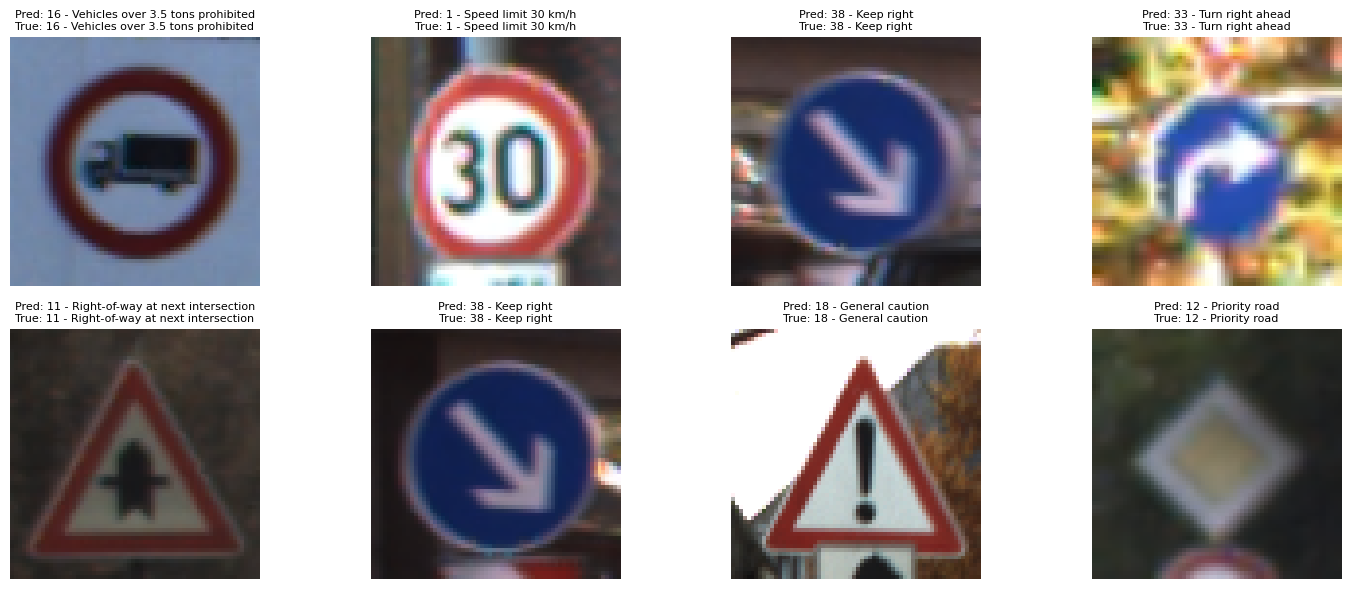

In [16]:
for images, labels_batch in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 6))

    for i in range(8):
        pred_id = int(predicted_labels[i])
        true_id = int(labels_batch[i].numpy())

        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(
            f"Pred: {pred_id} - {class_names[pred_id]}\n"
            f"True: {true_id} - {class_names[true_id]}",
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Conclusion

This notebook demonstrated a complete Basic CNN workflow for traffic sign classification using the GTSRB dataset.

Key points:

- GTSRB is a multi-class image classification dataset.
- The model predicts one class label for each input image.
- The CNN uses convolution, pooling, dropout, and dense layers.
- Evaluation is done using accuracy and classification report.
